In [1]:
import pandas as pd
net=pd.read_csv('netflix_data.csv')

In [2]:
net.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
net.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
net.shape

(8807, 12)

In [6]:
net['director'] = net['director'].fillna('Unknown')

In [7]:
net['cast']=net['cast'].fillna('unknown')
net['country']=net['country'].fillna('unknown')

In [8]:
net.duplicated().sum()

0

In [9]:
net = net.dropna(subset=['date_added'])

In [10]:
net['rating'].mode()

0    TV-MA
Name: rating, dtype: object

In [11]:
net['rating'] = net['rating'].fillna(net['rating'].mode()[0])

In [12]:
net[net['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [13]:
net.loc[net['duration'].isnull(), 'duration'] = net.loc[net['duration'].isnull(), 'rating']

In [17]:
net.loc[net['rating'].str.contains('min', na=False), 'rating'] = net['rating'].mode()[0]

In [29]:
net.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,False,False,False,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [31]:
net.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [33]:
net.shape

(8797, 12)

In [35]:
net.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8797,8797,8797,8797,8797,8797,8797,8797.000000,8797,8797,8797,8797
unique,8797,2,8797,4529,7683,749,1767,NaN,14,220,513,8765
top,s1,Movie,Dick Johnson Is Dead,Unknown,unknown,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2624,825,2812,109,NaN,3212,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.183472,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.822191,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [37]:
net['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [39]:
(net['type'].value_counts(normalize=True) * 100).round(2)

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64

In [41]:
net['country'].nunique()

749

In [43]:
net['director'].nunique()

4529

In [45]:
net['rating'].nunique()

14

In [47]:
net['rating'].value_counts()

rating
TV-MA       3212
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [49]:
net['country'].value_counts().head(10)

country
United States     2812
India              972
unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [51]:
net['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [53]:
net['director'].value_counts().head(10)

director
Unknown                   2624
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64

In [55]:
net['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [58]:
net['date_added'] = net['date_added'].str.strip()

In [60]:
net['date_added'] = pd.to_datetime(net['date_added'])

In [62]:
net['added_year'] = net['date_added'].dt.year

In [64]:
net['added_month'] = net['date_added'].dt.month_name()

In [66]:
net['added_month'].value_counts()

added_month
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
May          632
February     563
Name: count, dtype: int64

In [68]:
net['added_year'].value_counts().sort_index()

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [70]:
movies = net[net['type'] == 'Movie']

In [72]:
movies = net[net['type']=='Movie'].copy()

In [74]:
movies['duration'] = movies['duration'].str.replace(' min','')

In [76]:
movies['duration'] = movies['duration'].astype(int)

In [78]:
movies['duration'].mean()

99.56499755341706

In [80]:
movies['duration'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

In [82]:
movies['duration'].max()

312

In [84]:
movies['duration'].min()

3

In [86]:
tv = net[net['type'] == 'TV Show']

In [88]:
movies.groupby('rating')['duration'].mean()

rating
G            90.268293
NC-17       125.000000
NR           94.533333
PG           98.282230
PG-13       108.330612
R           106.720201
TV-14       110.290820
TV-G         79.666667
TV-MA        95.839865
TV-PG        94.851852
TV-Y         48.114504
TV-Y7        66.287770
TV-Y7-FV     68.400000
UR          106.333333
Name: duration, dtype: float64

In [93]:
net.groupby(['country','type']).size()

country                                              type   
, France, Algeria                                    Movie        1
, South Korea                                        TV Show      1
Argentina                                            Movie       38
                                                     TV Show     18
Argentina, Brazil, France, Poland, Germany, Denmark  Movie        1
                                                               ... 
Vietnam                                              Movie        7
West Germany                                         Movie        1
Zimbabwe                                             Movie        1
unknown                                              Movie      440
                                                     TV Show    390
Length: 849, dtype: int64

In [114]:
net['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

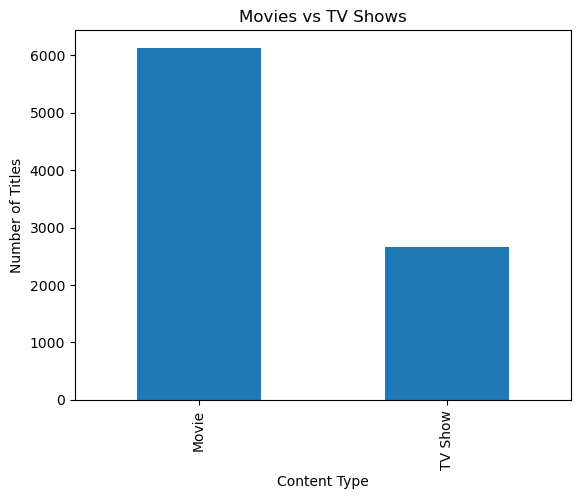

In [92]:
import matplotlib.pyplot as plt

net['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

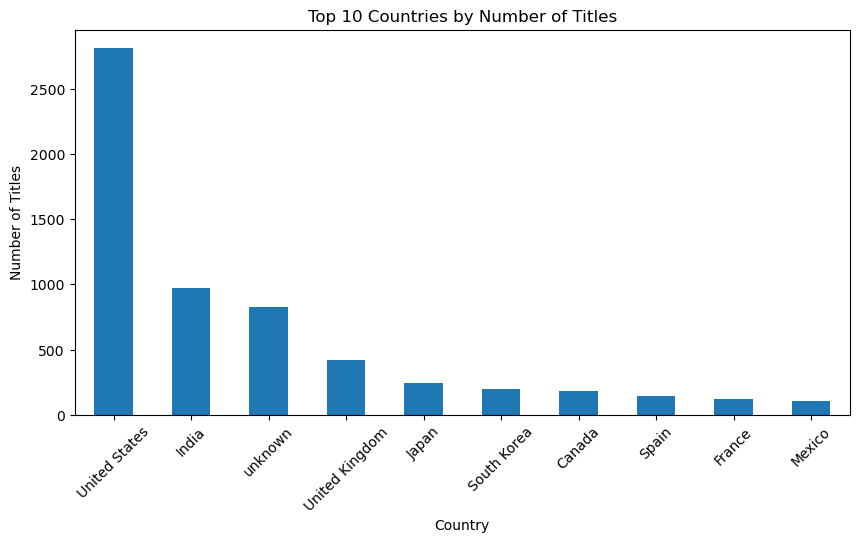

In [93]:
net['country'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

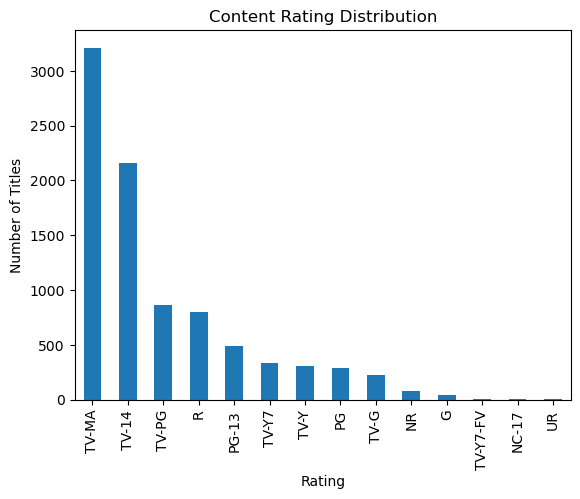

In [94]:
net['rating'].value_counts().plot(kind='bar')
plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.show()

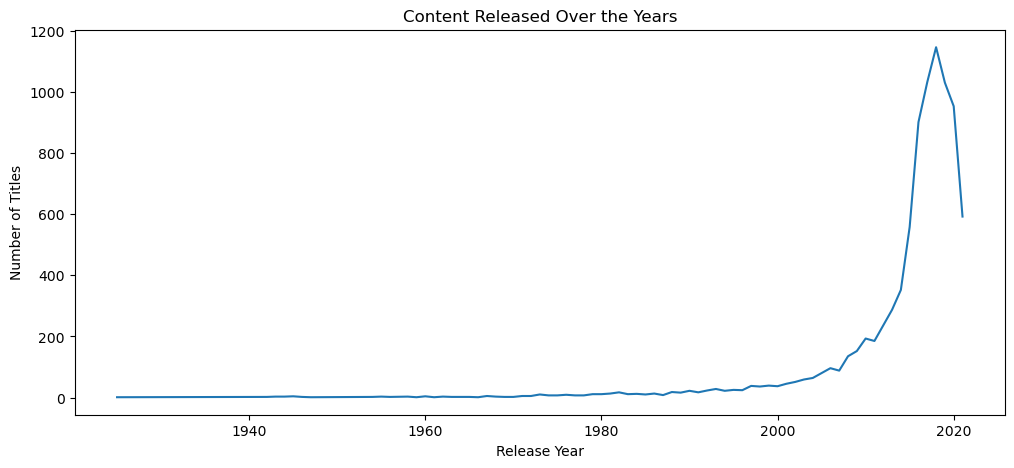

In [95]:
net['release_year'].value_counts().sort_index().plot(figsize=(12,5))
plt.title('Content Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

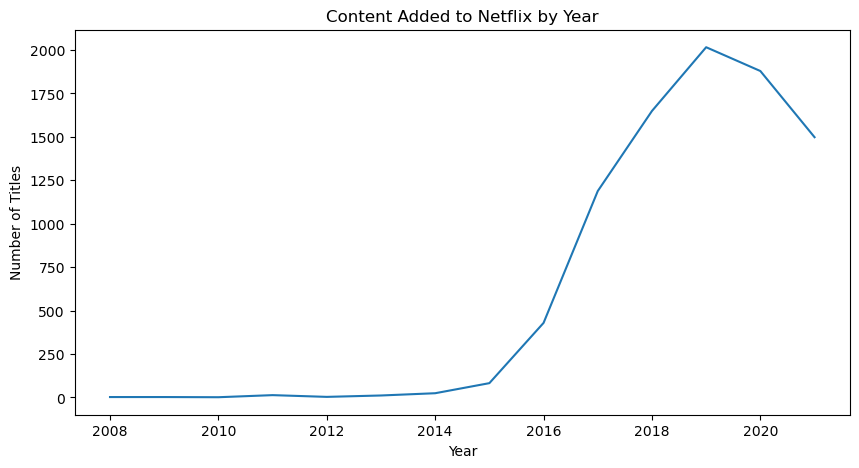

In [96]:
net.groupby('added_year').size().plot(figsize=(10,5))
plt.title('Content Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

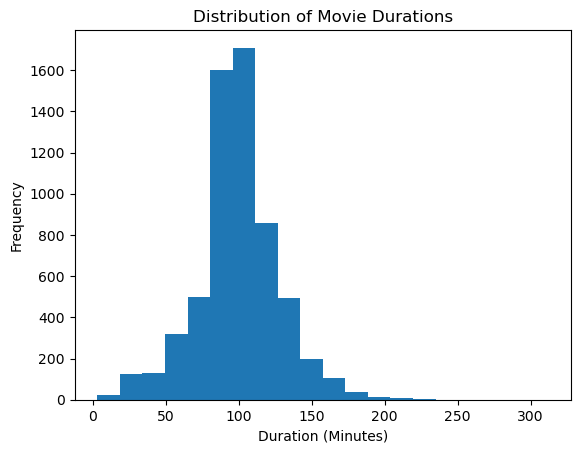

In [97]:
movies['duration'].plot(kind='hist', bins=20)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

In [98]:
net.to_csv(r"C:\Users\pravi\Downloads\netflix_cleaned.csv", index=False)

In [99]:
net[net['release_year'] == 1944]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
8419,s8420,Movie,The Memphis Belle: A Story of a\nFlying Fortress,William Wyler,unknown,United States,2017-03-31,1944,TV-PG,40 min,"Classic Movies, Documentaries",This documentary centers on the crew of the B-...,2017,March
8436,s8437,Movie,The Negro Soldier,Stuart Heisler,unknown,United States,2017-03-31,1944,TV-14,40 min,"Classic Movies, Documentaries",This documentary urged African Americans to en...,2017,March
8640,s8641,Movie,Tunisian Victory,"Frank Capra, John Huston, Hugh Stewart, Roy Bo...",Burgess Meredith,"United States, United Kingdom",2017-03-31,1944,TV-14,76 min,"Classic Movies, Documentaries",British and American troops join forces to lib...,2017,March


In [100]:
net[net['title'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month


In [101]:
net.loc[8412]

show_id                                                     s8413
type                                                        Movie
title                             The Man Who Would Be Polka King
director                               John Mikulak, Joshua Brown
cast                                        Jan Lewan, Greg Korin
country                                             United States
date_added                                    2018-01-12 00:00:00
release_year                                                 2009
rating                                                      TV-14
duration                                                   68 min
listed_in                         Documentaries, Music & Musicals
description     This irreverent documentary reveals how charmi...
added_year                                                   2018
added_month                                               January
Name: 8412, dtype: object

In [102]:
net.to_csv(
    r"C:\Users\pravi\Downloads\netflix_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

In [116]:
print(net.dtypes)

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
added_year               int32
added_month             object
dtype: object


In [118]:
net.to_excel(
    r"C:\Users\pravi\Downloads\netflix_cleaned.xlsx",
    index=False
)